<a href="https://colab.research.google.com/github/Quang365/mri-recognition/blob/main/notebooks/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.14.0+cpu
Device: cpu


In [32]:
from pathlib import Path

# Detect environment
if Path("/content/OASIS/keras_png_slices_data").exists():
    # Google Colab
    DATA_ROOT = Path("/content/OASIS/keras_png_slices_data")

elif Path("/home/groups/comp3710/OASIS").exists():
    # Rangpur
    DATA_ROOT = Path("/home/groups/comp3710/OASIS")

else:
    # Local machine
    DATA_ROOT = Path("../../keras_png_slices_data/keras_png_slices_data").resolve()

# Dataset directories
TRAIN_DIR = DATA_ROOT / "keras_png_slices_train"
VAL_DIR = DATA_ROOT / "keras_png_slices_validate"
TEST_DIR = DATA_ROOT / "keras_png_slices_test"

print("DATA_ROOT:", DATA_ROOT)
print("Exists:", DATA_ROOT.exists())

print("Train:", TRAIN_DIR.exists())
print("Validation:", VAL_DIR.exists())
print("Test:", TEST_DIR.exists())

DATA_ROOT: D:\uq\comp3710\Demo2\keras_png_slices_data\keras_png_slices_data
Exists: True
Train: True
Validation: True
Test: True


In [33]:
class MRIDataset(Dataset):
    """
    Dataset for loading preprocessed OASIS MRI slices.
    Each image is loaded as a single-channel grayscale tensor.
    """

    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        if os.path.exists(image_dir):
            self.image_files = sorted([
                f for f in os.listdir(image_dir)
                if f.lower().endswith(".png")
            ])
        else:
            self.image_files = []

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = os.path.join(
            self.image_dir,
            self.image_files[idx]
        )

        image = Image.open(image_path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image

In [34]:
def image_transform(image):
    array = np.array(image, dtype=np.float32) / 255.0
    return torch.from_numpy(array).unsqueeze(0)

train_dataset = MRIDataset(TRAIN_DIR, transform=image_transform)
val_dataset = MRIDataset(VAL_DIR, transform=image_transform)
test_dataset = MRIDataset(TEST_DIR, transform=image_transform)

print(f"Training images:   {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Testing images:    {len(test_dataset)}")

Training images:   9664
Validation images: 1120
Testing images:    544


### VAE Architecture

The encoder progressively downsamples the 256×256 MRI image and produces
two 16-dimensional vectors: `mu` and `logvar`, which parameterize the
latent Gaussian distribution.

The reparameterization trick samples

z = mu + std * epsilon

so that sampling remains compatible with backpropagation.

The decoder then reconstructs the MRI image from the sampled latent vector.

In [48]:
LATENT_DIM = 16


class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        # Encoder: [1, 256, 256] -> [256, 8, 8]
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )

        self.flatten_dim = 256 * 8 * 8

        # Latent distribution parameters
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # Latent vector -> decoder feature map
        self.decoder_input = nn.Linear(
            latent_dim,
            self.flatten_dim
        )

        # Decoder: [256, 8, 8] -> [1, 256, 256]
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                256, 256, kernel_size=4, stride=2, padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                256, 128, kernel_size=4, stride=2, padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                128, 64, kernel_size=4, stride=2, padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                64, 32, kernel_size=4, stride=2, padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                32, 1, kernel_size=4, stride=2, padding=1
            ),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = torch.flatten(x, start_dim=1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(-1, 256, 8, 8)

        return self.decoder(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)

        return reconstruction, mu, logvar

### VAE Loss

The VAE objective contains two terms:

1. Reconstruction loss (MSE): measures the pixel-wise difference between
   the original and reconstructed MRI.

2. KL divergence: regularizes the learned latent distribution toward
   a standard normal distribution.

Total Loss = Reconstruction Loss + KL Loss

In [49]:
def vae_loss(reconstruction, x, mu, logvar, beta=1.0):
    # Reconstruction loss
    recon_loss = F.mse_loss(
        reconstruction,
        x,
        reduction="sum"
    ) / x.size(0)

    # KL divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    ) / x.size(0)

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [50]:
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30

# DataLoaders are created only when the OASIS dataset is available.
if len(train_dataset) > 0:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print(f"Train batches:      {len(train_loader)}")
    print(f"Validation batches: {len(val_loader)}")
    print(f"Test batches:       {len(test_loader)}")

else:
    train_loader = None
    val_loader = None
    test_loader = None

    print("OASIS dataset is not available in this runtime.")
    print("DataLoaders will be created when running on Rangpur.")


model = VAE(latent_dim=LATENT_DIM).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print()
print(f"Batch size:        {BATCH_SIZE}")
print(f"Learning rate:     {LEARNING_RATE}")
print(f"Epochs:            {NUM_EPOCHS}")
print(f"Latent dimensions: {LATENT_DIM}")

Train batches:      302
Validation batches: 35
Test batches:       17

Batch size:        32
Learning rate:     0.001
Epochs:            30
Latent dimensions: 16


In [51]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    for images in loader:
        images = images.to(device, non_blocking=True)

        optimizer.zero_grad()

        reconstruction, mu, logvar = model(images)

        loss, recon_loss, kl_loss = vae_loss(
            reconstruction,
            images,
            mu,
            logvar
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    n_batches = len(loader)

    return (
        total_loss / n_batches,
        total_recon / n_batches,
        total_kl / n_batches
    )

In [52]:
@torch.no_grad()
def validate(model, loader, device):
    model.eval()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    for images in loader:
        images = images.to(device, non_blocking=True)

        reconstruction, mu, logvar = model(images)

        loss, recon_loss, kl_loss = vae_loss(
            reconstruction,
            images,
            mu,
            logvar
        )

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    n_batches = len(loader)

    return (
        total_loss / n_batches,
        total_recon / n_batches,
        total_kl / n_batches
    )

In [53]:
def train_vae(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=30,
    checkpoint_path="best_vae.pth"
):
    if train_loader is None or val_loader is None:
        print("Training skipped: OASIS dataset is not available.")
        return None

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_recon": [],
        "train_kl": [],
        "val_recon": [],
        "val_kl": []
    }

    best_val_loss = float("inf")

    for epoch in range(1, num_epochs + 1):

        train_loss, train_recon, train_kl = train_one_epoch(
            model,
            train_loader,
            optimizer,
            device
        )

        val_loss, val_recon, val_kl = validate(
            model,
            val_loader,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_recon"].append(train_recon)
        history["train_kl"].append(train_kl)
        history["val_recon"].append(val_recon)
        history["val_kl"].append(val_kl)

        print(
            f"Epoch [{epoch:02d}/{num_epochs}] | "
            f"Train: {train_loss:.2f} "
            f"(Recon: {train_recon:.2f}, KL: {train_kl:.2f}) | "
            f"Val: {val_loss:.2f} "
            f"(Recon: {val_recon:.2f}, KL: {val_kl:.2f})"
        )

        # Save the model with the best validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss,
                    "latent_dim": LATENT_DIM
                },
                checkpoint_path
            )

            print(
                f"  -> Saved best model "
                f"(validation loss: {best_val_loss:.2f})"
            )

    return history

In [54]:
# Set to True only when we intentionally want to train the VAE
RUN_TRAINING = False

if RUN_TRAINING:
    history = train_vae(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        num_epochs=NUM_EPOCHS,
        checkpoint_path="best_vae.pth"
    )
else:
    history = None
    print("Training disabled.")

Training disabled.


In [55]:
CHECKPOINT_PATH = Path("../checkpoints/best_vae.pth")

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

print("Checkpoint keys:", checkpoint.keys())
print("Saved epoch:", checkpoint.get("epoch"))
print("Saved validation loss:", checkpoint.get("val_loss"))
print("Latent dimension:", checkpoint.get("latent_dim"))

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Best VAE checkpoint loaded successfully.")

Checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss', 'latent_dim'])
Saved epoch: 11
Saved validation loss: 302.5155020577567
Latent dimension: 16
Best VAE checkpoint loaded successfully.


In [56]:
import numpy as np
import matplotlib.pyplot as plt

HISTORY_PATH = Path("../results/vae_history.npz")

history = np.load(HISTORY_PATH)

print("History keys:", history.files)

for key in history.files:
    print(f"{key}: shape={history[key].shape}")

History keys: ['train_loss', 'val_loss', 'train_recon', 'train_kl', 'val_recon', 'val_kl']
train_loss: shape=(30,)
val_loss: shape=(30,)
train_recon: shape=(30,)
train_kl: shape=(30,)
val_recon: shape=(30,)
val_kl: shape=(30,)


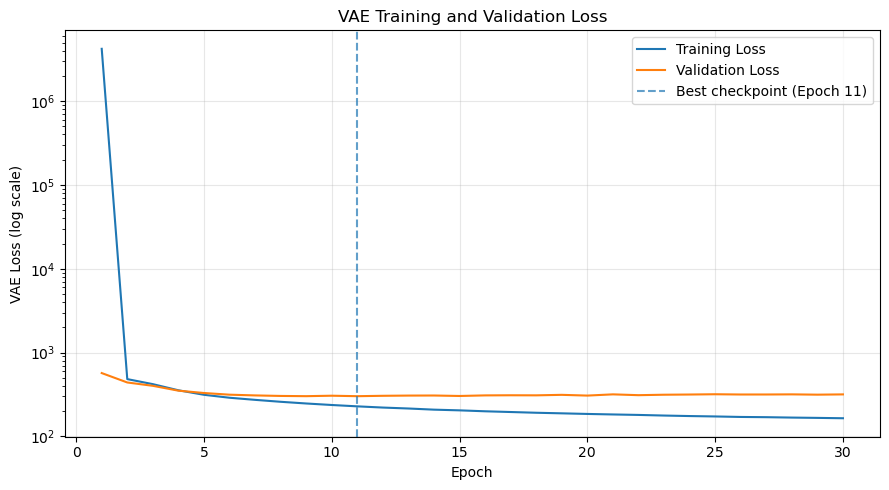

Best validation loss: 302.5155
Best validation epoch: 11


In [57]:
train_loss = history["train_loss"]
val_loss = history["val_loss"]

epochs = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(9, 5))

plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.axvline(
    x=11,
    linestyle="--",
    alpha=0.7,
    label="Best checkpoint (Epoch 11)"
)

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("VAE Loss (log scale)")
plt.title("VAE Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best validation loss: {val_loss.min():.4f}")
print(f"Best validation epoch: {val_loss.argmin() + 1}")

Local test batches: 17


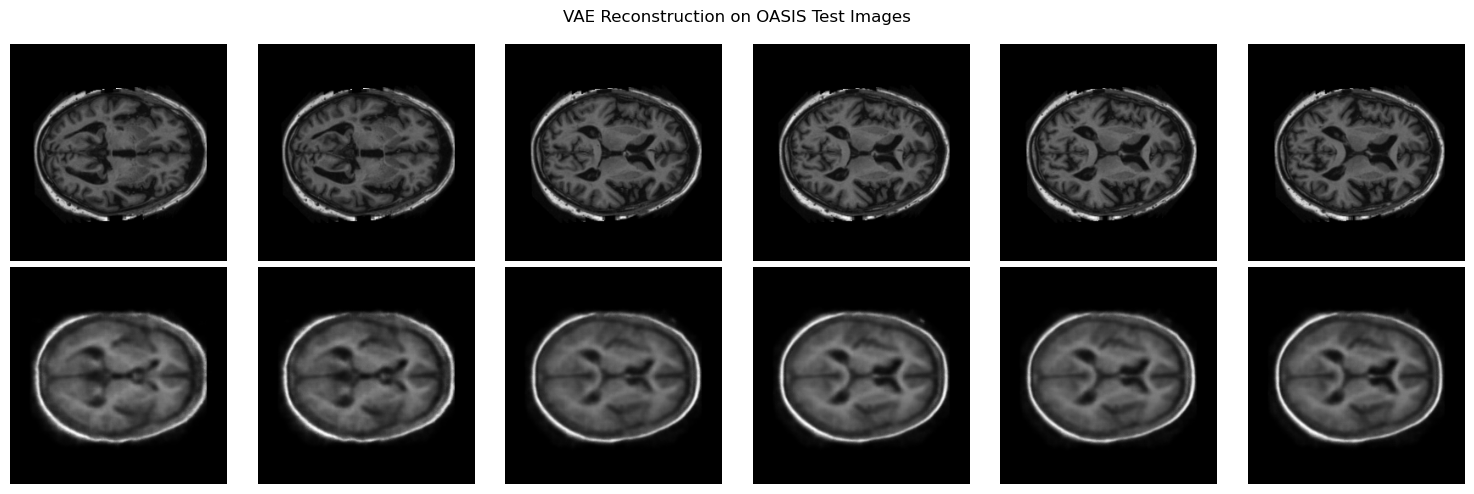

Input shape: torch.Size([32, 1, 256, 256])
Reconstruction shape: torch.Size([32, 1, 256, 256])
Reconstruction range: 8.560760827574241e-17 to 0.8723481297492981


In [58]:
model.eval()

# Local evaluation loader
# num_workers=0 avoids Windows/Jupyter multiprocessing issues.
local_test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Local test batches:", len(local_test_loader))

with torch.no_grad():
    images = next(iter(local_test_loader))
    images = images.to(device)

    reconstructions, mu, logvar = model(images)

# Show 6 original/reconstructed pairs
num_images = 6

fig, axes = plt.subplots(2, num_images, figsize=(15, 5))

for i in range(num_images):
    axes[0, i].imshow(
        images[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[0, i].axis("off")

    axes[1, i].imshow(
        reconstructions[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)

plt.suptitle("VAE Reconstruction on OASIS Test Images")
plt.tight_layout()
plt.show()

print("Input shape:", images.shape)
print("Reconstruction shape:", reconstructions.shape)
print(
    "Reconstruction range:",
    reconstructions.min().item(),
    "to",
    reconstructions.max().item()
)

### Latent Space Visualization

The VAE latent space has 16 dimensions. PCA is applied after training
only to project the 16-D latent means into 2-D for visualization.
It does not change the VAE latent dimension.

In [59]:
model.eval()

latent_vectors = []

with torch.no_grad():
    for images in local_test_loader:
        images = images.to(device)

        mu, logvar = model.encode(images)

        latent_vectors.append(mu.cpu().numpy())

latent_vectors = np.concatenate(latent_vectors, axis=0)

print("Latent vectors shape:", latent_vectors.shape)
print("Expected samples:", len(test_dataset))
print("Latent dimensions:", LATENT_DIM)

Latent vectors shape: (544, 16)
Expected samples: 544
Latent dimensions: 16


PCA output shape: (544, 2)
Explained variance ratio: [0.21800634 0.1599601 ]
Total explained variance: 0.37796646


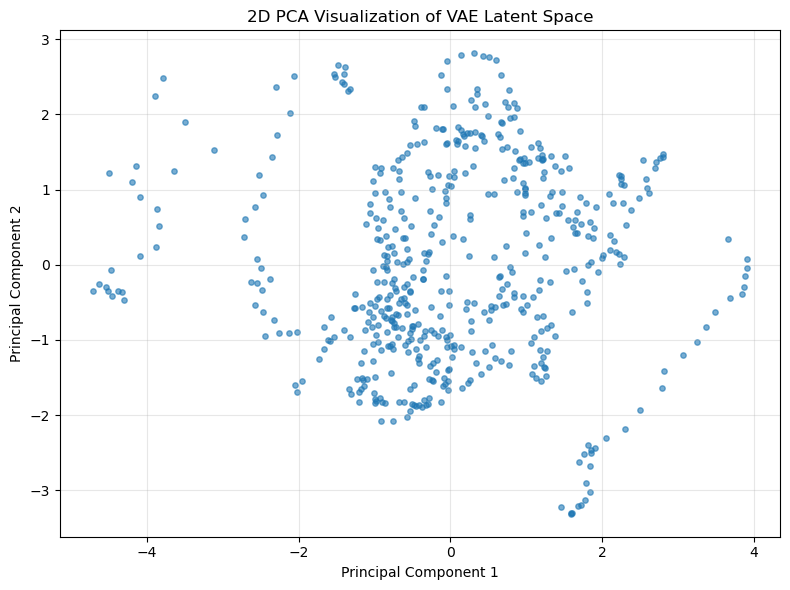

In [60]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_vectors)

print("PCA output shape:", latent_2d.shape)
print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)
print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

plt.figure(figsize=(8, 6))

plt.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    s=15,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Visualization of VAE Latent Space")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()